# Week 5 Final Exploration Notebook  
## AI-Assisted Emergency Department Triage Data Exploration

**Prepared by:** Shari Oliver  
**Programme:** CariSurg MedTech Pathways Healthcare AI Programme  
**Dataset:** `yaleemmlc_admissionprediction_triage.csv`  
**Project:** AI-Assisted Emergency Department Triage Support  

### Notebook Purpose

This notebook explores the de-identified emergency department triage dataset before baseline modelling in Week 6. The goal is to assess whether the dataset is suitable for AI-assisted triage modelling and to identify key data-quality concerns before any modelling is attempted.

The exploration focuses on:

- Dataset structure and feature types
- Missingness across clinical fields
- ESI target distribution
- Vital sign distributions and clinical plausibility
- Demographic and fairness-sensitive variables
- Chief complaint indicators
- Simple feature relationships with ESI
- A clinically justified top-10 feature shortlist

## Clinical Context

The dataset contains de-identified emergency department arrival records from Mercer General Hospital’s electronic health record system. It includes demographic information, arrival details, triage vital signs, disposition information and a large set of chief complaint indicators.

The target variable for this exploration is the Emergency Severity Index (ESI), where lower values represent higher acuity. In this context, ESI helps indicate how urgently a patient should be assessed or managed in the emergency department.

Because the dataset may eventually be used to support AI-assisted triage, the key question is not only whether the data can be analysed, but whether it is complete, clinically meaningful and reliable enough to build on safely.


## Loading Libraries and Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

OUTPUT_DIR = Path("week5_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Place the CSV beside this notebook, or set DATA_PATH (Colab).")

df = pd.read_csv(DATA_PATH, index_col=0)

print(f"Loaded {df.shape[0]:,} ED encounters with {df.shape[1]:,} columns.")
df.head()

Loaded 55,121 ED encounters with 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,...,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Dataset Overview

This section reviews the basic structure of the dataset, including the number of patient encounters, number of features, column names and data types. This is important because a triage model should only be developed after understanding what information is available and whether the variables are appropriate for use at the time of triage.

In [3]:
overview = pd.DataFrame({
    "metric": ["Number of encounters", "Number of columns", "Number of duplicated rows"],
    "value": [df.shape[0], df.shape[1], df.duplicated().sum()]
})

overview

,metric,value
0,Number of encounters,55121
1,Number of columns,225
2,Number of duplicated rows,0


In [14]:
dtype_summary = df.dtypes.astype(str).value_counts().reset_index()
dtype_summary.columns = ["data_type", "number_of_columns"]
dtype_summary

,data_type,number_of_columns
0,float64,210
1,object,15


In [15]:
column_profile = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
})

column_profile.sort_values("missing_percent", ascending=False).head(20)

,column_name,data_type,missing_count,missing_percent,unique_values
dep_name,dep_name,object,0,0.0,3
esi,esi,float64,0,0.0,5
age,age,float64,0,0.0,88
gender,gender,object,0,0.0,2
ethnicity,ethnicity,object,0,0.0,4
race,race,object,0,0.0,8
lang,lang,object,0,0.0,2
religion,religion,object,0,0.0,12
maritalstatus,maritalstatus,object,0,0.0,10
employstatus,employstatus,object,0,0.0,10


### Interpretation

The dataset contains many clinical and administrative variables, so the first step is to separate features that are likely available at triage from those that may occur later in the patient journey. This distinction is important because using post-triage information would make the model look better than it would perform in real clinical use.

## 2. Feature Family Mapping

The dataset contains many variables, so columns were grouped into clinically meaningful families. This helps separate vital signs, demographic fields, chief complaint indicators and possible leakage variables.

In [16]:
TARGET = "esi"

vital_cols = [
    col for col in df.columns
    if "triage_vital" in col.lower()
]

chief_complaint_cols = [
    col for col in df.columns
    if col.lower().startswith("cc_")
]

demographic_cols = [
    col for col in ["age", "gender", "race", "ethnicity", "insurance_status"]
    if col in df.columns
]

arrival_cols = [
    col for col in ["arrivalmode", "arrival_mode", "arrival_transport"]
    if col in df.columns
]

possible_leakage_cols = [
    col for col in df.columns
    if any(term in col.lower() for term in ["disposition", "admit", "ed_los", "hospital_los", "outcome"])
]

feature_families = pd.DataFrame({
    "feature_family": [
        "Target variable",
        "Triage vital signs",
        "Chief complaint indicators",
        "Demographic / fairness-sensitive variables",
        "Arrival-related variables",
        "Possible leakage variables"
    ],
    "number_of_columns": [
        1 if TARGET in df.columns else 0,
        len(vital_cols),
        len(chief_complaint_cols),
        len(demographic_cols),
        len(arrival_cols),
        len(possible_leakage_cols)
    ]
})

feature_families

,feature_family,number_of_columns
0,Target variable,1
1,Triage vital signs,7
2,Chief complaint indicators,200
3,Demographic / fairness-sensitive variables,5
4,Arrival-related variables,1
5,Possible leakage variables,1


In [17]:
print("Target:", TARGET)
print("Vital sign columns:", vital_cols)
print("Demographic columns:", demographic_cols)
print("Arrival columns:", arrival_cols)
print("Possible leakage columns:", possible_leakage_cols[:20])

Target: esi
Vital sign columns: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp']
Demographic columns: ['age', 'gender', 'race', 'ethnicity', 'insurance_status']
Arrival columns: ['arrivalmode']
Possible leakage columns: ['disposition']


### Interpretation

The feature family review shows which variables are most relevant to triage modelling. Vital signs, demographics, arrival information and chief complaint indicators are likely to be available at or near triage. Possible leakage variables must be reviewed carefully because variables recorded after triage should not be used to predict triage acuity.

## 3. Missingness Review

Missingness is one of the most important data-quality issues for this project. If key clinical fields are missing, the model may not have enough information to support safe triage predictions. Missing ESI labels are especially important because ESI is the target variable for Week 6 baseline modelling.

In [18]:
missingness = pd.DataFrame({
    "feature": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2)
}).sort_values("missing_percent", ascending=False)

missingness.head(25)

,feature,missing_count,missing_percent
0,dep_name,0,0.0
1,esi,0,0.0
2,age,0,0.0
3,gender,0,0.0
4,ethnicity,0,0.0
5,race,0,0.0
6,lang,0,0.0
7,religion,0,0.0
8,maritalstatus,0,0.0
9,employstatus,0,0.0


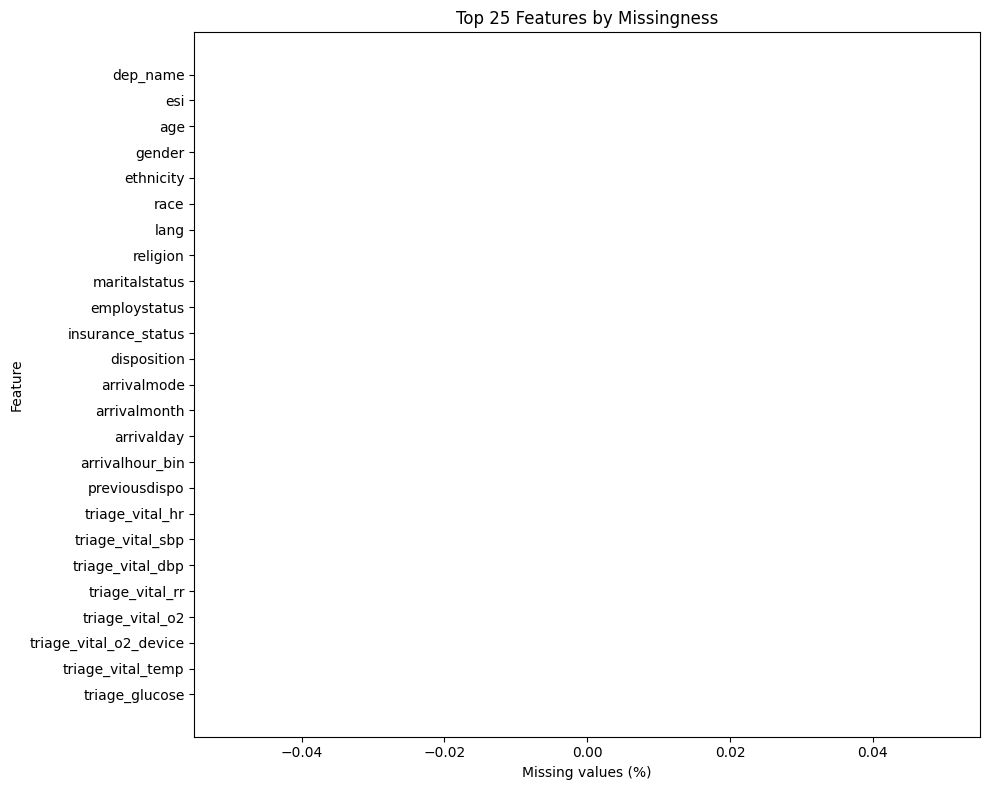

In [19]:
top_missing = missingness.head(25)

plt.figure(figsize=(10, 8))
plt.barh(top_missing["feature"], top_missing["missing_percent"])
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Top 25 Features by Missingness")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("SOliver_Week5_Missingness_BarChart.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
target_missing = df[TARGET].isna().sum() if TARGET in df.columns else None

vital_missingness = missingness[missingness["feature"].isin(vital_cols)]
chief_complaint_missingness = missingness[missingness["feature"].isin(chief_complaint_cols)]
demographic_missingness = missingness[missingness["feature"].isin(demographic_cols)]

print("Missing ESI labels:", target_missing)
print("\nVital sign missingness:")
display(vital_missingness)
print("\nDemographic missingness:")
display(demographic_missingness)

Missing ESI labels: 0

Vital sign missingness:


,feature,missing_count,missing_percent
17,triage_vital_hr,0,0.0
18,triage_vital_sbp,0,0.0
19,triage_vital_dbp,0,0.0
20,triage_vital_rr,0,0.0
21,triage_vital_o2,0,0.0
22,triage_vital_o2_device,0,0.0
23,triage_vital_temp,0,0.0



Demographic missingness:


,feature,missing_count,missing_percent
2,age,0,0.0
3,gender,0,0.0
4,ethnicity,0,0.0
5,race,0,0.0
10,insurance_status,0,0.0


### Interpretation

The missingness review identifies which variables are most reliable for Week 6 modelling. Missing ESI labels cannot be used for supervised modelling because the target is unknown. Missing vital signs require careful handling because they may reflect real emergency department workflow conditions rather than random absence. For the baseline model, missingness should be documented and handled transparently rather than silently ignored.

## 4. ESI Target Variable Review

The Emergency Severity Index is the target variable for baseline modelling. Before modelling, it is important to review whether the ESI levels are complete and whether the categories are balanced.

In [22]:
esi_counts = df[TARGET].value_counts(dropna=False).sort_index()
esi_percent = (esi_counts / len(df) * 100).round(2)

esi_summary = pd.DataFrame({
    "esi_level": esi_counts.index.astype(str),
    "count": esi_counts.values,
    "percent": esi_percent.values
})

esi_summary

,esi_level,count,percent
0,1.0,77,0.14
1,2.0,17924,32.52
2,3.0,27010,49.00
3,4.0,8896,16.14
4,5.0,1214,2.20


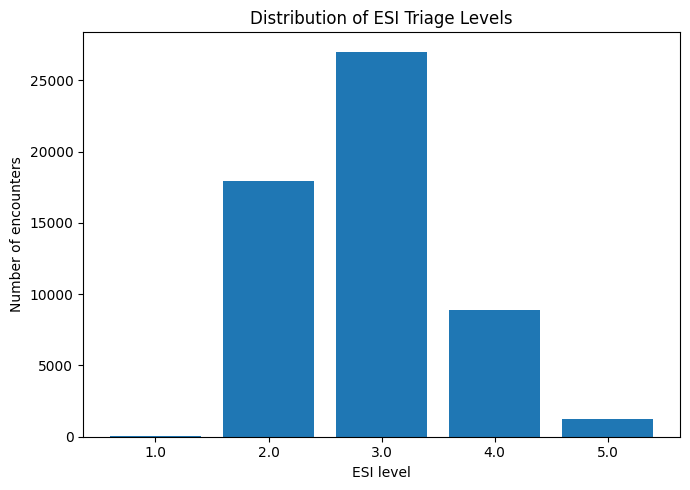

In [23]:
plt.figure(figsize=(7, 5))
plt.bar(esi_summary["esi_level"], esi_summary["count"])
plt.xlabel("ESI level")
plt.ylabel("Number of encounters")
plt.title("Distribution of ESI Triage Levels")
plt.tight_layout()
plt.savefig("SOliver_Week5_ESI_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The ESI distribution shows whether the target variable is suitable for modelling and whether some acuity levels are more common than others. If the target is imbalanced, Week 6 evaluation should not rely only on overall accuracy. It should also review performance across ESI levels, especially for high-acuity patients.

## 5. Vital Sign Distributions and Clinical Plausibility

Vital signs are clinically important because they reflect the patient's physiological status at triage. This section reviews summary statistics and flags values that may be clinically implausible.

In [24]:
vital_summary = df[vital_cols].describe().T
vital_summary["missing_count"] = df[vital_cols].isna().sum()
vital_summary["missing_percent"] = (df[vital_cols].isna().mean() * 100).round(2)
vital_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0,0,0.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0,0,0.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0,0,0.0
triage_vital_rr,55121.0,17.842073,2.066015,8.0,16.0,18.0,18.0,66.0,0,0.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0,0,0.0
triage_vital_o2_device,55121.0,0.065510,0.247427,0.0,0.0,0.0,0.0,1.0,0,0.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0,0,0.0


In [25]:
plausible_ranges = {
    "triage_vital_hr": (20, 250),
    "triage_vital_sbp": (40, 300),
    "triage_vital_dbp": (20, 200),
    "triage_vital_rr": (5, 80),
    "triage_vital_o2": (50, 100),
    "triage_vital_temp": (30, 45),
    "triage_vital_glucose": (20, 1000)
}

plausibility_rows = []

for col, (low, high) in plausible_ranges.items():
    if col in df.columns:
        values = pd.to_numeric(df[col], errors="coerce")
        below_range = (values < low).sum()
        above_range = (values > high).sum()
        plausibility_rows.append({
            "feature": col,
            "plausible_low": low,
            "plausible_high": high,
            "below_range_count": below_range,
            "above_range_count": above_range,
            "total_flagged": below_range + above_range
        })

plausibility_report = pd.DataFrame(plausibility_rows)
plausibility_report

,feature,plausible_low,plausible_high,below_range_count,above_range_count,total_flagged
0,triage_vital_hr,20,250,0,0,0
1,triage_vital_sbp,40,300,0,0,0
2,triage_vital_dbp,20,200,0,0,0
3,triage_vital_rr,5,80,0,0,0
4,triage_vital_o2,50,100,0,0,0
5,triage_vital_temp,30,45,0,55121,55121


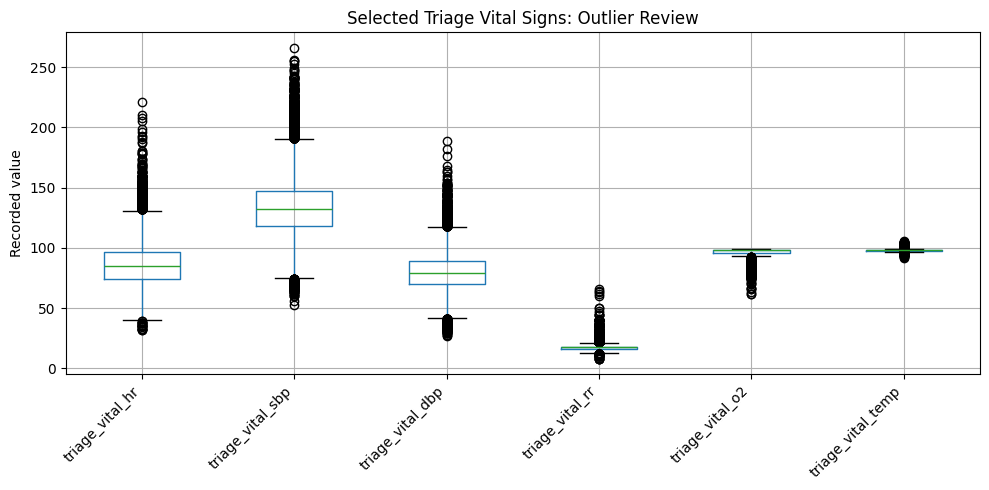

In [26]:
selected_vitals = [col for col in [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp"
] if col in df.columns]

plt.figure(figsize=(10, 5))
df[selected_vitals].boxplot()
plt.title("Selected Triage Vital Signs: Outlier Review")
plt.ylabel("Recorded value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("SOliver_Week5_Selected_Vital_Signs_Outlier_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Extreme vital signs should not be removed automatically because they may reflect true clinical deterioration. However, values outside broad plausible clinical ranges should be reviewed because they may represent documentation errors, unit errors or incorrect data entry. For Week 6, these values should be flagged and handled using transparent rules.

## 6. Demographic and Fairness-Sensitive Variables

This section reviews demographic variables that may be important for equity auditing. These variables should be handled carefully and should not automatically be treated as clinical predictors without governance justification.

In [27]:
for col in demographic_cols:
    print(f"\n{col.upper()}")
    display(df[col].value_counts(dropna=False).head(15))


AGE


,count
age,
53.0,1285
54.0,1278
52.0,1196
55.0,1185
57.0,1156
59.0,1139
51.0,1131
56.0,1126
58.0,1109



GENDER


,count
gender,
Female,31744
Male,23377



RACE


,count
race,
White or Caucasian,29435
Black or African American,15963
Other,9016
Patient Refused,370
Asian,175
Unknown,76
American Indian or Alaska Native,66
Native Hawaiian or Other Pacific Islander,20



ETHNICITY


,count
ethnicity,
Non-Hispanic,45142
Hispanic or Latino,9888
Patient Refused,56
Unknown,35



INSURANCE_STATUS


,count
insurance_status,
Medicaid,21427
Medicare,17581
Commercial,14056
Other,1883
Self pay,174


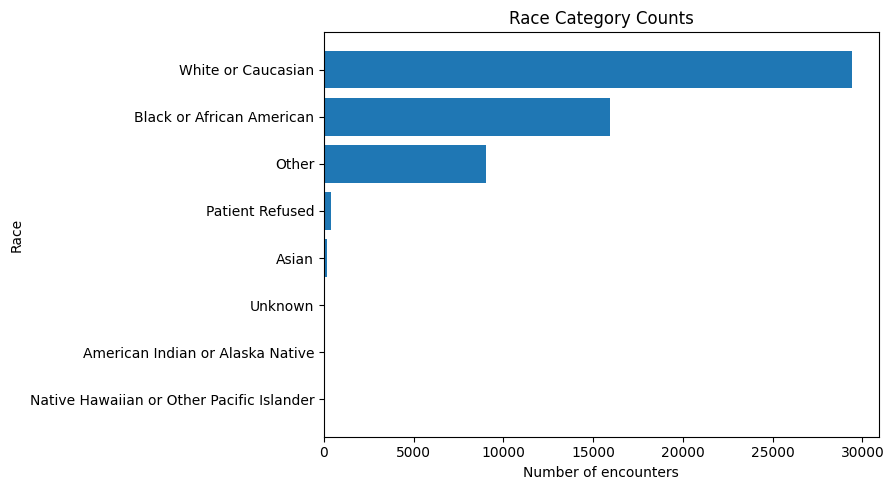

In [28]:
if "race" in df.columns:
    race_counts = df["race"].value_counts(dropna=False).head(10)

    plt.figure(figsize=(9, 5))
    plt.barh(race_counts.index.astype(str), race_counts.values)
    plt.xlabel("Number of encounters")
    plt.ylabel("Race")
    plt.title("Race Category Counts")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("SOliver_Week5_Race_Category_Counts.png", dpi=300, bbox_inches="tight")
    plt.show()

In [29]:
if "race" in df.columns and TARGET in df.columns:
    race_esi = pd.crosstab(df["race"], df[TARGET], normalize="index") * 100
    race_esi.round(1)

### Interpretation

Demographic variables are important for understanding representation and for later checking whether a model performs differently across patient groups. At this stage, these variables are most useful for equity auditing and subgroup review rather than automatic inclusion as predictors.

**Interpretation:**  
The race category count plot shows how many records are available for each racial group in the dataset. This is important for equity analysis because percentage-based comparisons can be misleading when a category has a small sample size. Groups with fewer records may show unstable patterns, so subgroup performance should be interpreted cautiously during model development.

## 7. Chief Complaint Indicator Review

Chief complaint indicators are clinically important because they describe why the patient presented to the emergency department. However, some complaint indicators may be very rare, which can make them unstable for modelling.

In [30]:
cc_prevalence = df[chief_complaint_cols].mean().sort_values(ascending=False)

top_cc = cc_prevalence.head(20).reset_index()
top_cc.columns = ["chief_complaint", "prevalence"]

top_cc

,chief_complaint,prevalence
0,cc_abdominalpain,0.121859
1,cc_other,0.081475
2,cc_chestpain,0.067343
3,cc_shortnessofbreath,0.056204
4,cc_backpain,0.036229
5,cc_fall,0.034941
6,cc_cough,0.026106
7,cc_dizziness,0.023439
8,cc_legpain,0.022931
9,cc_emesis,0.022659


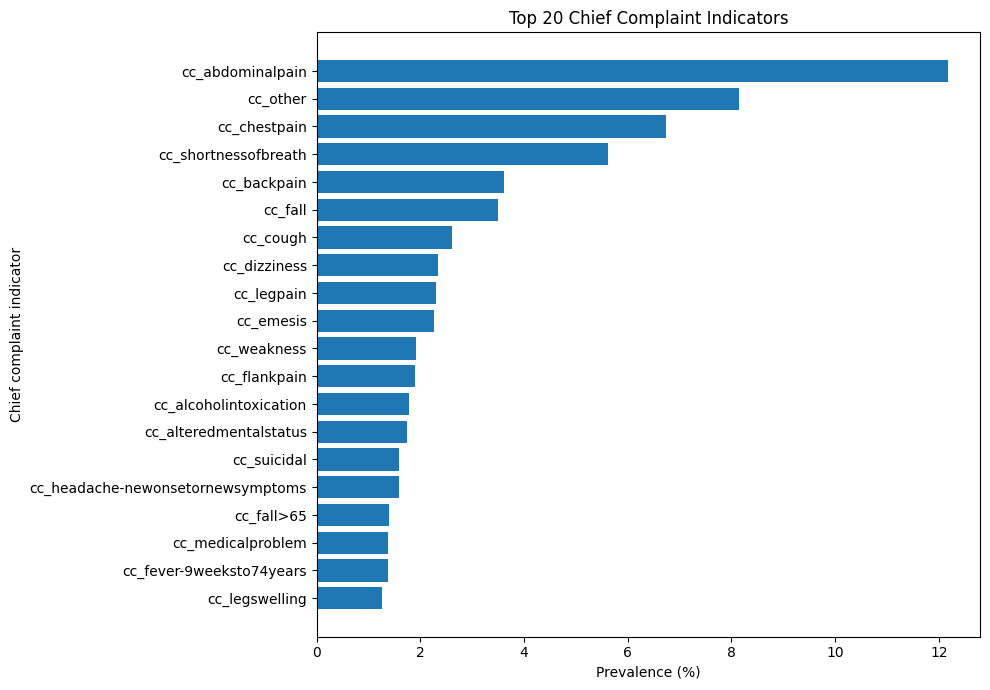

In [31]:
plt.figure(figsize=(10, 7))
plt.barh(top_cc["chief_complaint"], top_cc["prevalence"] * 100)
plt.xlabel("Prevalence (%)")
plt.ylabel("Chief complaint indicator")
plt.title("Top 20 Chief Complaint Indicators")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("SOliver_Week5_Top_Chief_Complaints.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
rare_cc = cc_prevalence[cc_prevalence < 0.005]

print(f"Number of chief complaint indicators: {len(chief_complaint_cols)}")
print(f"Number of rare chief complaint indicators below 0.5% prevalence: {len(rare_cc)}")

rare_cc.head(20)

Number of chief complaint indicators: 200
Number of rare chief complaint indicators below 0.5% prevalence: 149


,0
cc_dentalpain,0.004880
cc_constipation,0.004826
cc_anxiety,0.004826
cc_generalizedbodyaches,0.004662
cc_handpain,0.004608
cc_hematuria,0.004372
cc_elevatedbloodsugar-symptomatic,0.004336
cc_giproblem,0.004281
cc_woundinfection,0.004209
cc_elevatedbloodsugar-nosymptoms,0.004118


### Interpretation

Chief complaint indicators provide useful clinical context, but very rare indicators may not be reliable as individual model inputs. For Week 6, rare complaint indicators may need to be grouped into broader categories or handled carefully to avoid unstable predictions.

## 8. Simple Feature Signal Review

This section reviews simple relationships between selected clinical features and ESI. These relationships are not proof of causation, but they help identify variables that may be useful for baseline modelling.

In [36]:
## 8. Simple Feature Signal Review

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove the target and possible leakage variables
candidate_numeric_cols = [
    col for col in numeric_cols
    if col != TARGET and col not in possible_leakage_cols
]

# Keep only columns that have enough non-missing values and more than one unique value
valid_corr_cols = []

for col in candidate_numeric_cols:
    usable_values = df[col].dropna()

    if usable_values.shape[0] >= 30 and usable_values.nunique() > 1:
        valid_corr_cols.append(col)

print(f"Numeric candidate columns before filtering: {len(candidate_numeric_cols)}")
print(f"Numeric candidate columns after filtering: {len(valid_corr_cols)}")

# Calculate correlations safely
correlations = df[valid_corr_cols].corrwith(df[TARGET]).dropna()
correlations_abs = correlations.abs().sort_values(ascending=False)

top_correlations = pd.DataFrame({
    "feature": correlations_abs.head(20).index,
    "correlation_with_esi": correlations.loc[correlations_abs.head(20).index].round(3),
    "absolute_correlation": correlations_abs.head(20).round(3).values
})

top_correlations

Numeric candidate columns before filtering: 209
Numeric candidate columns after filtering: 208


,feature,correlation_with_esi,absolute_correlation
age,age,-0.237,0.237
triage_vital_o2_device,triage_vital_o2_device,-0.209,0.209
triage_vital_o2,triage_vital_o2,0.178,0.178
cc_chestpain,cc_chestpain,-0.164,0.164
cc_shortnessofbreath,cc_shortnessofbreath,-0.150,0.150
cc_suicidal,cc_suicidal,-0.143,0.143
cc_backpain,cc_backpain,0.142,0.142
cc_alcoholintoxication,cc_alcoholintoxication,-0.142,0.142
cc_rash,cc_rash,0.134,0.134
cc_alteredmentalstatus,cc_alteredmentalstatus,-0.132,0.132


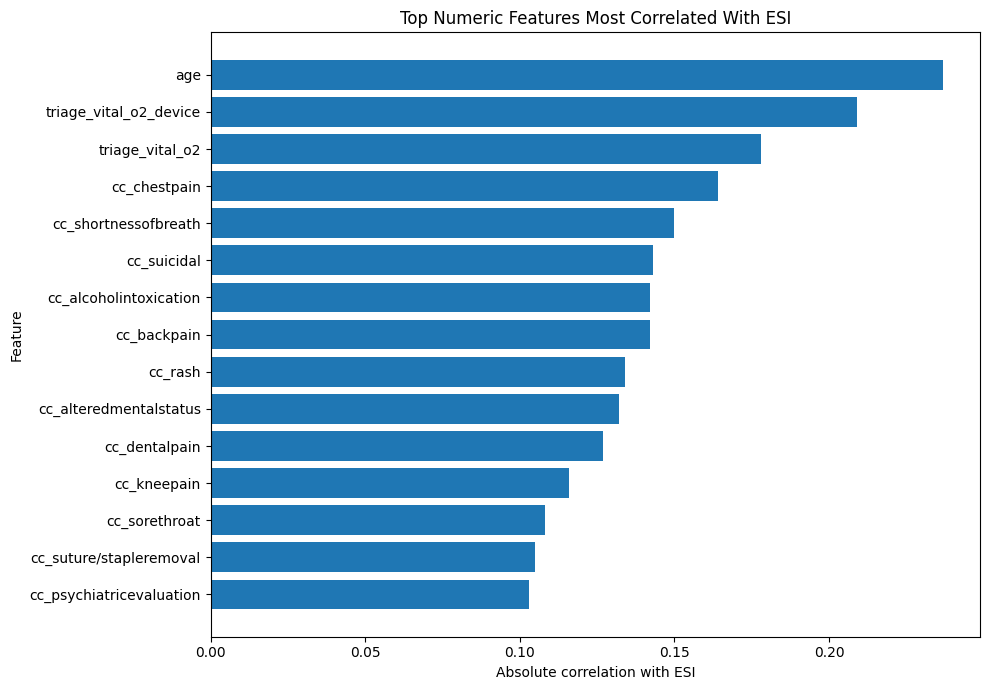

In [37]:
plot_corr = top_correlations.head(15).sort_values("absolute_correlation")

plt.figure(figsize=(10, 7))
plt.barh(plot_corr["feature"], plot_corr["absolute_correlation"])
plt.xlabel("Absolute correlation with ESI")
plt.ylabel("Feature")
plt.title("Top Numeric Features Most Correlated With ESI")
plt.tight_layout()
plt.savefig("SOliver_Week5_Top_Correlations_With_ESI.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

This section reviews simple relationships between numeric features and ESI. Columns with too many missing values or no variation were excluded before calculating correlations because they cannot provide a meaningful signal. These correlations are only an early guide and should not be treated as proof of clinical importance. The Week 6 feature shortlist should combine these results with clinical reasoning.

## 9. Initial Top-10 Feature Shortlist

The feature shortlist below combines clinical reasoning with the Week 5 data exploration. These features are recommended for initial consideration in Week 6 baseline modelling.

In [35]:
top10_features = pd.DataFrame({
    "rank": range(1, 11),
    "feature": [
        "triage_vital_rr",
        "triage_vital_o2",
        "triage_vital_sbp",
        "triage_vital_hr",
        "triage_vital_temp",
        "triage_vital_glucose",
        "age",
        "arrival mode",
        "cc_chestpain",
        "cc_shortnessofbreath"
    ],
    "clinical_reason": [
        "May indicate respiratory distress, sepsis, shock or deterioration.",
        "Reflects oxygenation and urgent respiratory/cardiovascular risk.",
        "May indicate shock, sepsis, bleeding or cardiovascular instability.",
        "May reflect pain, fever, dehydration, arrhythmia or shock.",
        "May indicate infection, sepsis or systemic illness.",
        "May identify diabetic emergencies or altered mental status risk.",
        "Older patients may deteriorate faster or present atypically.",
        "Ambulance or urgent transport may suggest higher acuity.",
        "May indicate time-sensitive cardiovascular emergencies.",
        "May indicate respiratory distress, heart failure or pulmonary embolism."
    ]
})

top10_features

,rank,feature,clinical_reason
0,1,triage_vital_rr,"May indicate respiratory distress, sepsis, sho..."
1,2,triage_vital_o2,Reflects oxygenation and urgent respiratory/ca...
2,3,triage_vital_sbp,"May indicate shock, sepsis, bleeding or cardio..."
3,4,triage_vital_hr,"May reflect pain, fever, dehydration, arrhythm..."
4,5,triage_vital_temp,"May indicate infection, sepsis or systemic ill..."
5,6,triage_vital_glucose,May identify diabetic emergencies or altered m...
6,7,age,Older patients may deteriorate faster or prese...
7,8,arrival mode,Ambulance or urgent transport may suggest high...
8,9,cc_chestpain,May indicate time-sensitive cardiovascular eme...
9,10,cc_shortnessofbreath,"May indicate respiratory distress, heart failu..."


### Interpretation

These features are clinically reasonable starting points because they are commonly available at triage and relate directly to acuity. Before Week 6 modelling, the exact column names should be checked against the dataset, missingness should be reviewed and possible leakage variables should be excluded.

## 10. Final Data-Quality Conclusion

The dataset is suitable for continued exploration and Week 6 baseline modelling, but it is not ready for clinical deployment. The main strengths are the presence of clinically relevant triage features, a meaningful ESI target and a rich set of chief complaint indicators. The main concerns are missingness, possible ESI imbalance, clinically implausible values, sparse chief complaint indicators, potential data leakage and single-site generalisability.

For Week 6, the modelling approach should be treated as a controlled baseline experiment. The model should exclude post-triage variables, document missingness handling, review performance across ESI levels and include subgroup performance checks where appropriate.